In [438]:
import pandas as pd   
import numpy as np 
from scipy.stats import kde 
import statsmodels.formula.api as smf 
import statsmodels.api as sm 
import seaborn as sns 
import matplotlib.pyplot as plt   

### Загрузка и внешний анализ данных

In [439]:
df = pd.read_excel(r"D:\Data_for_analyse\7.xlsx", usecols = "A:X",nrows=151)
pd.set_option('display.max_columns', None)
df

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,cylindernumber,doornumber,price,fueltype_num,aspiration_num,carbody_num,drivewheel_num,enginetype_num,fuelsystem_num
0,155,0,95.7,169.7,63.6,59.1,2290,92,3.05,3.03,9.0,62,4800,27,32,4,4,7898.0,gas,std,wagon,4wd,ohc,2bbl
1,100,0,97.2,173.4,65.2,54.7,2324,120,3.33,3.47,8.5,97,5200,27,34,4,4,8949.0,gas,std,hatchback,fwd,ohc,2bbl
2,123,1,93.7,167.3,63.8,50.8,2191,98,2.97,3.23,9.4,68,5500,31,38,4,4,7609.0,gas,std,sedan,fwd,ohc,2bbl
3,139,2,93.7,156.9,63.4,53.7,2050,97,3.62,2.36,9.0,69,4900,31,36,4,2,5118.0,gas,std,hatchback,fwd,ohcf,2bbl
4,99,2,95.1,162.4,63.8,53.3,2008,97,3.15,3.29,9.4,69,5200,31,37,4,2,8249.0,gas,std,hardtop,fwd,ohc,2bbl
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,86,1,96.3,172.4,65.4,51.6,2365,122,3.35,3.46,8.5,88,5000,25,32,4,4,6989.0,gas,std,sedan,fwd,ohc,2bbl
146,51,1,93.1,159.1,64.2,54.1,1890,91,3.03,3.15,9.0,68,5000,30,31,4,2,5195.0,gas,std,hatchback,fwd,ohc,2bbl
147,20,1,94.5,155.9,63.6,52.0,1874,90,3.03,3.11,9.6,70,5400,38,43,4,2,6295.0,gas,std,hatchback,fwd,ohc,2bbl
148,18,0,110.0,197.0,70.9,56.3,3505,209,3.62,3.39,8.0,182,5400,15,20,6,4,36880.0,gas,std,sedan,rwd,ohc,mpfi


In [440]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            150 non-null    int64  
 1   symboling         150 non-null    int64  
 2   wheelbase         150 non-null    float64
 3   carlength         150 non-null    float64
 4   carwidth          150 non-null    float64
 5   carheight         150 non-null    float64
 6   curbweight        150 non-null    int64  
 7   enginesize        150 non-null    int64  
 8   boreratio         150 non-null    float64
 9   stroke            150 non-null    float64
 10  compressionratio  150 non-null    float64
 11  horsepower        150 non-null    int64  
 12  peakrpm           150 non-null    int64  
 13  citympg           150 non-null    int64  
 14  highwaympg        150 non-null    int64  
 15  cylindernumber    150 non-null    int64  
 16  doornumber        150 non-null    int64  
 1

Как видно, в данных нету пропущенных значений

### Описательные статистики

In [441]:
df.describe(include="all")

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,cylindernumber,doornumber,price,fueltype_num,aspiration_num,carbody_num,drivewheel_num,enginetype_num,fuelsystem_num
count,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.00000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150,150,150,150,150,150
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2,5,3,6,8
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,gas,std,sedan,fwd,ohc,mpfi
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,135,121,70,87,109,69
mean,106.540000,0.880000,98.522000,174.094667,65.822000,53.739333,2557.24000,127.526667,3.329733,3.253567,10.159467,103.873333,5091.333333,25.406667,30.886667,4.393333,3.080000,13126.687780,NaN,NaN,NaN,NaN,NaN,NaN
std,59.911078,1.284497,5.859849,12.170372,2.096173,2.471472,518.22939,40.959580,0.258267,0.326569,4.022529,39.251777,471.992303,6.738746,7.142403,1.067498,1.000134,8119.430117,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.00000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,2.000000,2.000000,5118.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,50.250000,0.000000,94.500000,166.425000,64.025000,52.000000,2190.25000,98.000000,3.150000,3.100000,8.525000,70.000000,4800.000000,20.000000,25.000000,4.000000,2.000000,7895.750000,NaN,NaN,NaN,NaN,NaN,NaN
50%,111.500000,1.000000,96.950000,173.200000,65.500000,54.100000,2417.00000,120.000000,3.310000,3.290000,9.000000,95.000000,5100.000000,24.000000,30.000000,4.000000,4.000000,9984.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,160.750000,2.000000,102.400000,184.325000,66.575000,55.700000,2969.25000,144.750000,3.587500,3.447500,9.400000,116.000000,5475.000000,29.750000,34.000000,4.000000,4.000000,16322.000000,NaN,NaN,NaN,NaN,NaN,NaN


### Гипотезы
1. Размер двигателя не влияет на цену автомобиля (отсутствует корреляция между размером двигателя и ценой)
2. Автомобили с полным приводом имеют более высокую максимальную скорость, чем автомобили с передним или задним приводом.
3. С увеличением объема двигателя расход топлива увеличивается

### Корреляция

In [442]:
round(df.var(numeric_only=True), 2)

car_ID                  3589.34
symboling                  1.65
wheelbase                 34.34
carlength                148.12
carwidth                   4.39
carheight                  6.11
curbweight            268561.70
enginesize              1677.69
boreratio                  0.07
stroke                     0.11
compressionratio          16.18
horsepower              1540.70
peakrpm               222776.73
citympg                   45.41
highwaympg                51.01
cylindernumber             1.14
doornumber                 1.00
price               65925145.43
dtype: float64

In [443]:
corr_matrix = df.corr(numeric_only=True)
def highlight_corr(val):
    if val != 1.0 and abs(val) > 0.6:  
        return 'background-color: #3B467D; text-decoration: underline'
    else:
        return ''

corr_matrix.style.applymap(highlight_corr)

C:\Users\User\AppData\Local\Temp\ipykernel_30116\2643206225.py:8: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  corr_matrix.style.applymap(highlight_corr)


,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,cylindernumber,doornumber,price
car_ID,1.000000,-0.133545,0.131480,0.157178,0.020720,0.255655,0.040986,-0.066951,0.234576,-0.112982,0.169514,-0.037771,-0.236592,0.009975,0.023341,-0.147216,0.178375,-0.159675
symboling,-0.133545,1.000000,-0.534815,-0.337956,-0.226837,-0.548591,-0.203064,-0.044076,-0.121481,-0.047611,-0.143673,0.091145,0.258970,-0.012933,0.051178,-0.028976,-0.682075,-0.034165
wheelbase,0.131480,-0.534815,1.000000,0.868473,0.796925,0.625863,0.750013,0.500998,0.472421,0.143513,0.220128,0.335452,-0.340985,-0.465784,-0.536424,0.280459,0.469560,0.499425
carlength,0.157178,-0.337956,0.868473,1.000000,0.847728,0.517414,0.874357,0.664458,0.603476,0.119649,0.125888,0.578854,-0.222434,-0.697824,-0.725953,0.419062,0.406734,0.654442
carwidth,0.020720,-0.226837,0.796925,0.847728,1.000000,0.319401,0.859044,0.726220,0.519421,0.178532,0.149313,0.610475,-0.221286,-0.642436,-0.688603,0.538980,0.233171,0.721611
carheight,0.255655,-0.548591,0.625863,0.517414,0.319401,1.000000,0.318699,0.027951,0.214744,-0.057348,0.266533,-0.087070,-0.299572,-0.095102,-0.135858,-0.087815,0.590358,0.113086
curbweight,0.040986,-0.203064,0.750013,0.874357,0.859044,0.318699,1.000000,0.843186,0.651687,0.131628,0.113856,0.756386,-0.218937,-0.772200,-0.812650,0.613490,0.203701,0.812601
enginesize,-0.066951,-0.044076,0.500998,0.664458,0.726220,0.027951,0.843186,1.000000,0.598193,0.170119,0.000268,0.840896,-0.166969,-0.684138,-0.705508,0.855871,-0.011029,0.877002
boreratio,0.234576,-0.121481,0.472421,0.603476,0.519421,0.214744,0.651687,0.598193,1.000000,-0.001405,-0.015227,0.570703,-0.246067,-0.605523,-0.619876,0.243571,0.114927,0.531055
stroke,-0.112982,-0.047611,0.143513,0.119649,0.178532,-0.057348,0.131628,0.170119,-0.001405,1.000000,0.169164,0.071600,-0.056119,-0.019633,-0.021003,-0.028886,0.012374,0.035174


<Axes: >

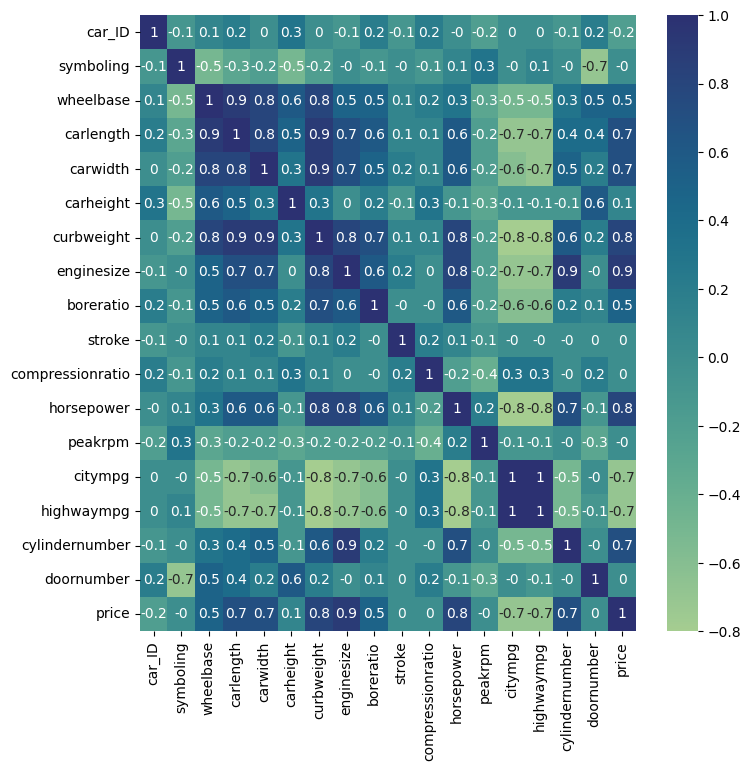

In [444]:
plt.subplots(figsize=(8, 8))
sns.heatmap(round(df.corr(numeric_only=True), 1), annot = True, cmap="crest")

### Числовые данные
- **symboling**:
    *Математическое ожидание*: `0.88`, говорит о том, что в среднем оценка безопасности машин ближе к 1.*(Дисперсия, станартное отклонение)*: `(1.65 , 1.28)`, что говорит о небольшом разбросе. *Медиана*: `1`, то есть более менее равномерно распределенно 
- **wheelbase**: 
    *Математическое ожидание*: `98.52`, *(Дисперсия, станартное отклонение)*: `(34.5, 1.65)`, что говорит о небольшом разбросе. *Медиана*: `96.95` примерно равно среднему, что говорит о нормальном распределении. 
    
Точно такая же картинка наблюдается в следующих признаках:
`carlength	carwidth	carheight	curbweight	boreratio	stroke	compressionratio	horsepower	peakrpm	citympg	highwaympg	cylindernumber` все они распределены ближе к нормальному распределению

В тоже время:
- **price**:
<p>Математическое ожидание: 13126.69.<p\>
<p>(Дисперсия, стандартное отклонение): (65925145.43 , 8119.43). <p\>
<p>Медиана: 19984. Цена автомобиля больше смещена к началу - правосторонняя ассиметрия. Следует привести ее в нормальное распределение - логарифмировать значения price



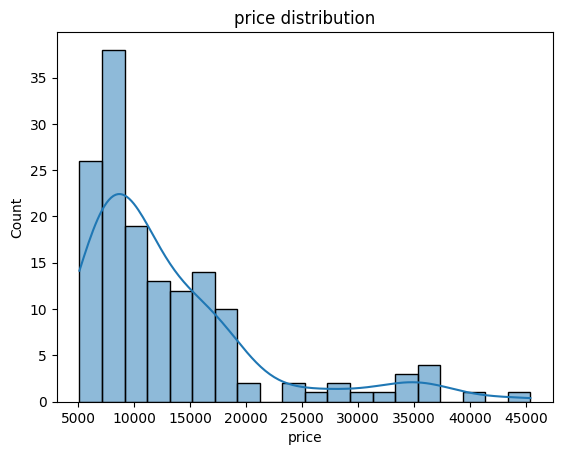

In [445]:
sns.histplot(df["price"], kde=True, bins = 20)
plt.title('price distribution')
plt.show()

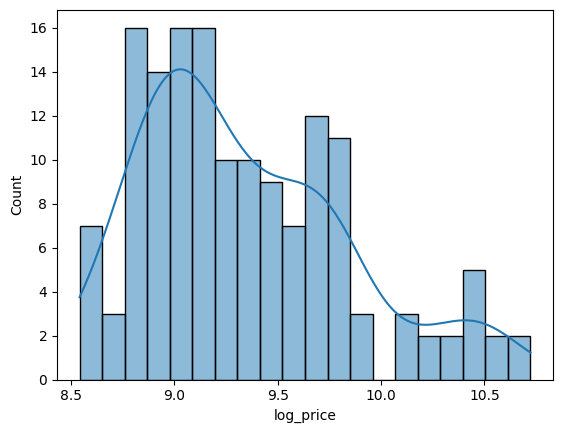

In [446]:
df["log_price"] = np.log(df["price"])
sns.histplot(df["log_price"], kde=True, bins = 20)
plt.show()

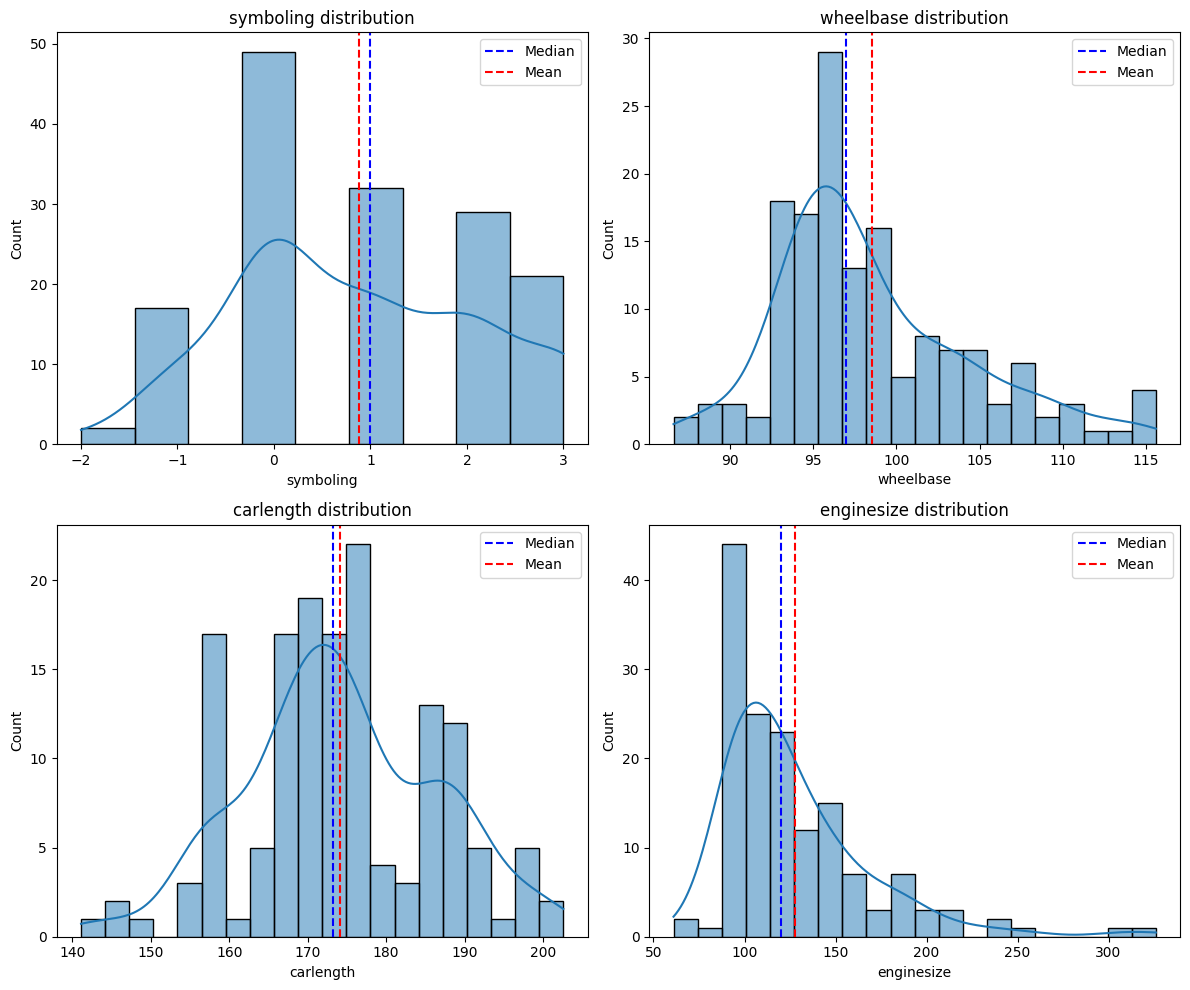

In [447]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))

sns.histplot(df['symboling'], kde=True, ax=axes[0, 0])
axes[0, 0].axvline(df['symboling'].median(), color='blue', linestyle='--', label='Median')
axes[0, 0].axvline(df['symboling'].mean(), color='red', linestyle='--', label='Mean')
axes[0, 0].set_title('symboling distribution')
axes[0, 0].legend()

sns.histplot(df['wheelbase'], kde=True, bins=20, ax=axes[0, 1])
axes[0, 1].axvline(df['wheelbase'].median(), color='blue', linestyle='--', label='Median')
axes[0, 1].axvline(df['wheelbase'].mean(), color='red', linestyle='--', label='Mean')
axes[0, 1].set_title('wheelbase distribution')
axes[0, 1].legend()

sns.histplot(df['carlength'], kde=True, bins=20, ax=axes[1, 0])
axes[1, 0].axvline(df['carlength'].median(), color='blue', linestyle='--', label='Median')
axes[1, 0].axvline(df['carlength'].mean(), color='red', linestyle='--', label='Mean')
axes[1, 0].set_title('carlength distribution')
axes[1, 0].legend()

sns.histplot(df['enginesize'], kde=True, bins=20, ax=axes[1, 1])
axes[1, 1].axvline(df['enginesize'].median(), color='blue', linestyle='--', label='Median')
axes[1, 1].axvline(df['enginesize'].mean(), color='red', linestyle='--', label='Mean')
axes[1, 1].set_title('enginesize distribution')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

Возможно нужно прибегнуть к возведению в логарифм от **enginesize**, так как оно имеет правосторонюю ассиметрию

<Axes: xlabel='log_enginesize', ylabel='Count'>

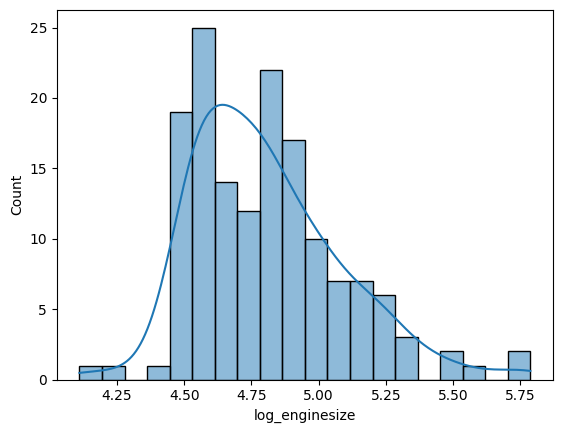

In [448]:
df["log_enginesize"] = np.log(df["enginesize"])
sns.histplot(df['log_enginesize'], kde=True, bins=20)

### Качественные данные


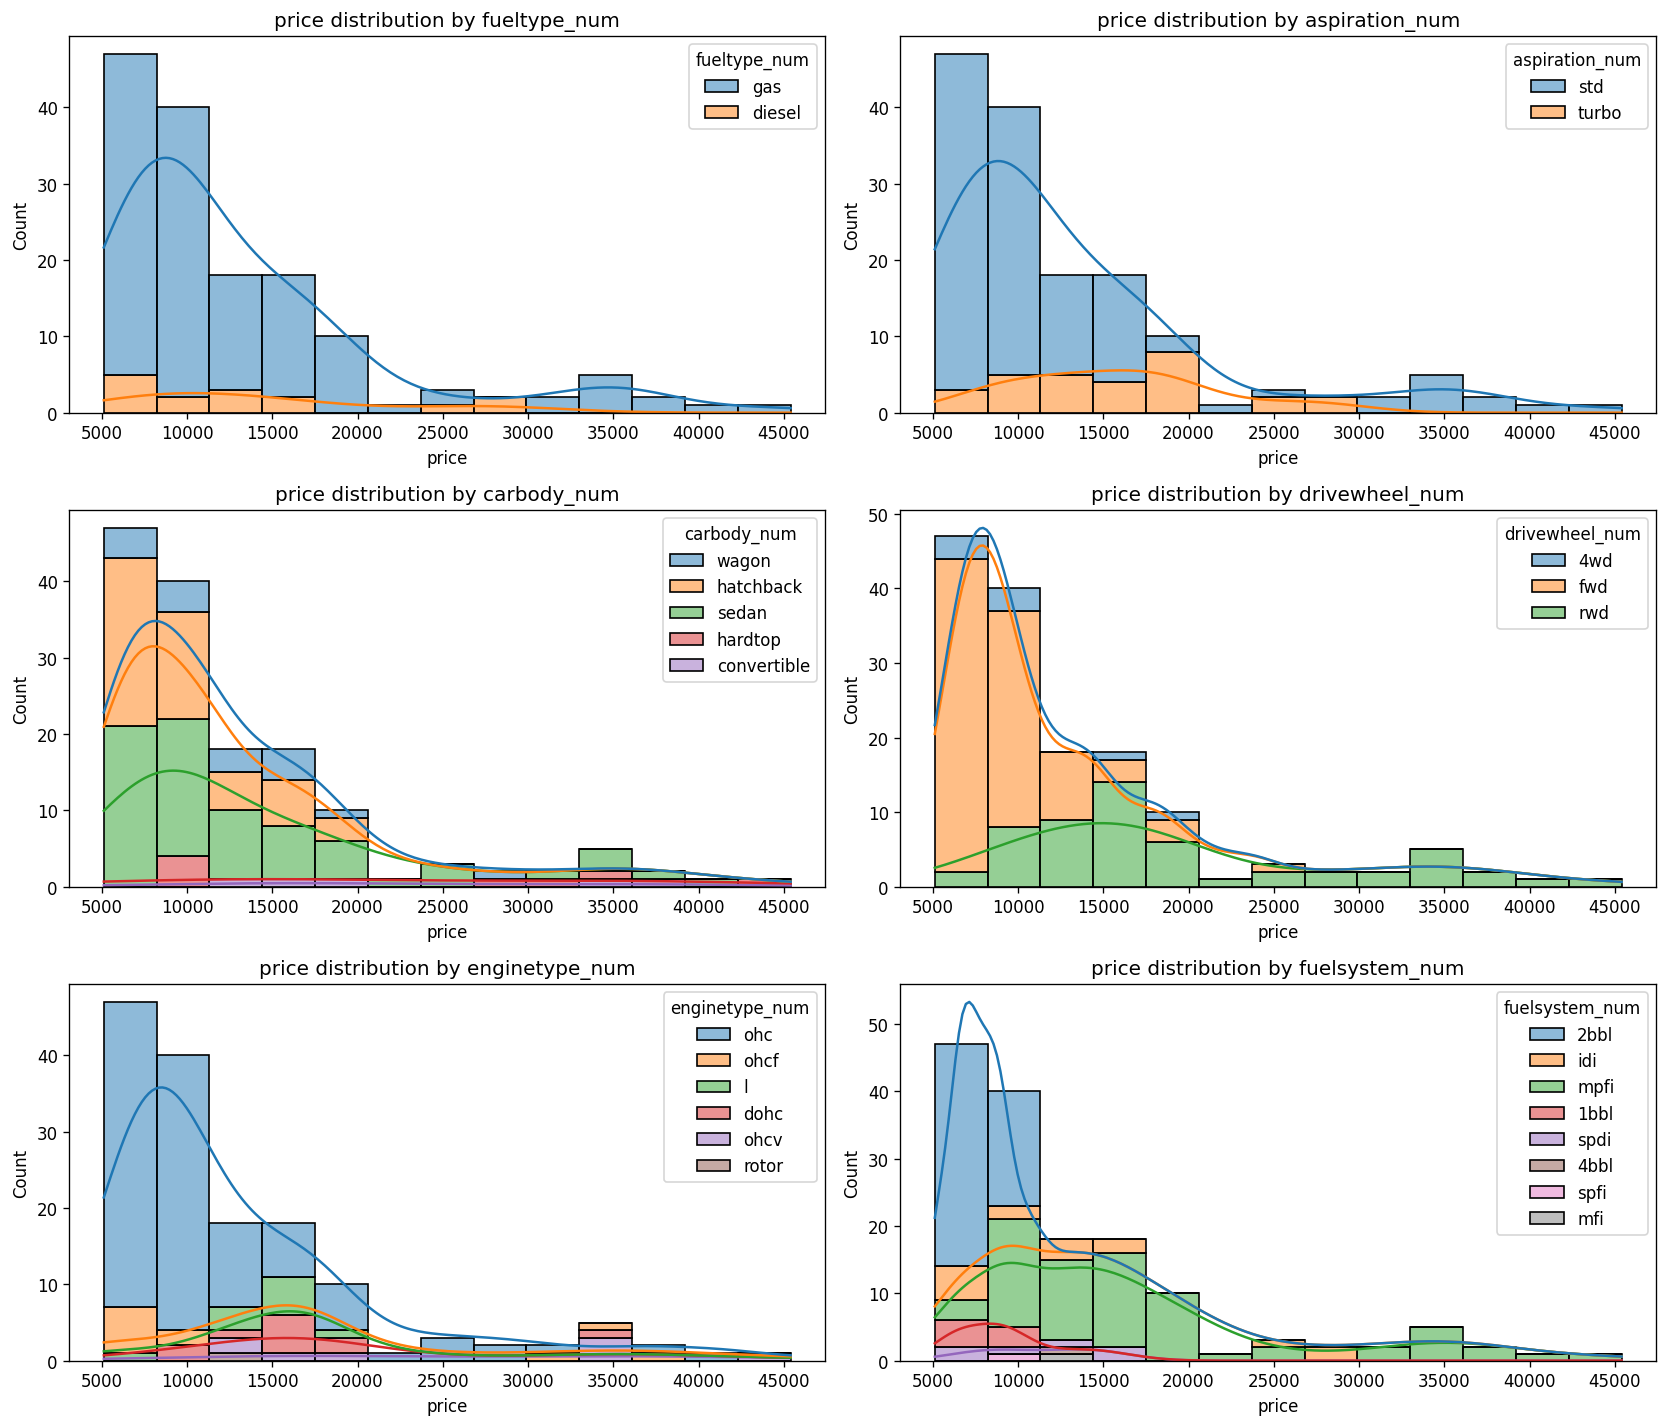

In [449]:
categ_vars = ['fueltype_num', 'aspiration_num', 'carbody_num', 'drivewheel_num', 'enginetype_num', 'fuelsystem_num']
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 12), dpi=120)
axes = axes.flatten()  

for i, cat_var in enumerate(categ_vars):
    sns.histplot(data=df, x='price', hue=cat_var, multiple='stack', ax=axes[i], kde=True)
    axes[i].set_title(f'price distribution by {cat_var}')

plt.tight_layout()
plt.show()

Для определения какие качественные данные нам больше подойдут проведем тест ANOVA

In [450]:
from statsmodels.formula.api import ols

anova_results = {}
categ_vars = ['fueltype_num', 'aspiration_num', 'carbody_num', 'drivewheel_num', 'enginetype_num', 'fuelsystem_num']

for var in categ_vars:
    model = ols(f'price ~ C({var})', data=df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    p_value = anova_table['PR(>F)'][0] 
    anova_results[var] = p_value

anova_results

C:\Users\User\AppData\Local\Temp\ipykernel_30116\787641603.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value = anova_table['PR(>F)'][0]
C:\Users\User\AppData\Local\Temp\ipykernel_30116\787641603.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value = anova_table['PR(>F)'][0]
C:\Users\User\AppData\Local\Temp\ipykernel_30116\787641603.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value = anova_table['PR(>F)'][0

{'fueltype_num': 0.5324943904626074,
 'aspiration_num': 0.04777830498623739,
 'carbody_num': 5.484730478014421e-06,
 'drivewheel_num': 2.1563663908814963e-15,
 'enginetype_num': 2.101148274026566e-06,
 'fuelsystem_num': 5.479134380911951e-10}

Опираясь на тест, можно сказать, что **drivewheel_num**, **enginetype_num**, and **fuelsystem_num** могут нам помочь в построение регрессионной модели. Можно попробовать их включить в модель

Преобразуем в фиктивные переменные drivewheel_num, enginetype_num, fuelsystem_num

In [451]:
categorical_vars = ["drivewheel_num", "enginetype_num", "fuelsystem_num"]
df_dummies = pd.get_dummies(df, columns=categorical_vars,dtype=float)
df_dummies.columns[23:]

Index(['drivewheel_num_4wd', 'drivewheel_num_fwd', 'drivewheel_num_rwd',
       'enginetype_num_dohc', 'enginetype_num_l', 'enginetype_num_ohc',
       'enginetype_num_ohcf', 'enginetype_num_ohcv', 'enginetype_num_rotor',
       'fuelsystem_num_1bbl', 'fuelsystem_num_2bbl', 'fuelsystem_num_4bbl',
       'fuelsystem_num_idi', 'fuelsystem_num_mfi', 'fuelsystem_num_mpfi',
       'fuelsystem_num_spdi', 'fuelsystem_num_spfi'],
      dtype='object')

## Регрессия

Убираем из модели те аргументы, которые сильно коррелируют с **log_price** и не значимы в модели

In [452]:
X1 = df_dummies[['symboling', 'wheelbase', 'drivewheel_num_4wd', 
         'drivewheel_num_fwd', 'drivewheel_num_rwd',
         'enginetype_num_dohc', 'enginetype_num_l', 
         'enginetype_num_ohc', 'fuelsystem_num_2bbl']]
y = df_dummies["log_price"]
X1 = sm.add_constant(X1) 
model1 = sm.OLS(y, X1).fit() 
display(model1.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              log_price   R-squared:                       0.709
Model:                            OLS   Adj. R-squared:                  0.692
Method:                 Least Squares   F-statistic:                     42.94
Date:                Wed, 09 Oct 2024   Prob (F-statistic):           3.69e-34
Time:                        00:54:52   Log-Likelihood:                -16.997
No. Observations:                 150   AIC:                             51.99
Df Residuals:                     141   BIC:                             79.09
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   4.0260      0.466      8.638      0.000       3.105       4.947
symboling               0.0608      0.023      2.590      0.011       0.014       0.107
wheelbase               0.0440      0.006      7.192      0.000       0.032       0.056
drivewheel_num_4wd      1.2798      0.168      7.638      0.000       0.949       1.611
drivewheel_num_fwd      1.1972      0.156      7.677      0.000       0.889       1.506
drivewheel_num_rwd      1.5490      0.172      8.997      0.000       1.209       1.889
enginetype_num_dohc    -0.3071      0.108     -2.833      0.005      -0.521      -0.093
enginetype_num_l       -0.7361      0.120     -6.129      0.000      -0.974      -0.499
enginetype_num_ohc     -0.3237      0.074     -4.384      0.000      -0.470      -0.178
fuelsystem_num_2bbl    -0.2989      0.059     -5.082      0.000      -0.415      -0.183
==============================================================================
Omnibus:                        6.009   Durbin-Watson:                   2.059
Prob(Omnibus):                  0.050   Jarque-Bera (JB):                5.594
Skew:                           0.410   Prob(JB):                       0.0610
Kurtosis:                       3.473   Cond. No.                     2.59e+17
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 2.17e-29. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

In [453]:
predictions1 = model1.predict(X1)
MSE1 = sum((y - predictions1)**2)/len(y)
MAE1 = sum(abs(y - predictions1))/len(y)
print(f"R^2: {model1.rsquared}")
print(f"MSE: {MSE1}")
print(f"MAE: {MAE1}")

R^2: 0.7090005589679893
MSE: 0.07344296690252476
MAE: 0.2137118325226785


### Мультиколлиниарность

Проверим VIF

In [454]:
from patsy import dmatrices
from statsmodels.stats.outliers_influence import variance_inflation_factor

y, X = dmatrices("log_price ~ symboling + wheelbase + drivewheel_num_4wd + drivewheel_num_fwd + drivewheel_num_rwd + enginetype_num_dohc + enginetype_num_l + enginetype_num_ohc + fuelsystem_num_2bbl", data=df_dummies, return_type='dataframe')

vif = pd.DataFrame()
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif['variable'] = X.columns
vif

C:\Users\User\AppData\Roaming\Python\Python312\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
C:\Users\User\AppData\Roaming\Python\Python312\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,VIF,variable
0,0.000000,Intercept
1,1.734273,symboling
2,2.453345,wheelbase
3,inf,drivewheel_num_4wd
4,inf,drivewheel_num_fwd
5,inf,drivewheel_num_rwd
6,1.532490,enginetype_num_dohc
7,1.723082,enginetype_num_l
8,2.079399,enginetype_num_ohc
9,1.475878,fuelsystem_num_2bbl


Видно, что значения drivewheel_num_4wd, drivewheel_num_fwd, drivewheel_num_rwd = inf. Уберем из модели. В остальном все хорошо, VIF не привышает 5

In [455]:
X1 = df_dummies[['symboling', 'wheelbase',
         'enginetype_num_dohc', 'enginetype_num_l', 
         'enginetype_num_ohc', 'fuelsystem_num_2bbl']]
y = df_dummies["log_price"]
X1 = sm.add_constant(X1) 
model1 = sm.OLS(y, X1).fit() 
display(model1.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              log_price   R-squared:                       0.642
Model:                            OLS   Adj. R-squared:                  0.627
Method:                 Least Squares   F-statistic:                     42.74
Date:                Wed, 09 Oct 2024   Prob (F-statistic):           1.42e-29
Time:                        00:54:52   Log-Likelihood:                -32.543
No. Observations:                 150   AIC:                             79.09
Df Residuals:                     143   BIC:                             100.2
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   4.4683      0.662      6.750      0.000       3.160       5.777
symboling               0.0701      0.026      2.735      0.007       0.019       0.121
wheelbase               0.0540      0.006      8.359      0.000       0.041       0.067
enginetype_num_dohc    -0.2664      0.117     -2.268      0.025      -0.499      -0.034
enginetype_num_l       -0.7308      0.130     -5.602      0.000      -0.989      -0.473
enginetype_num_ohc     -0.4269      0.076     -5.633      0.000      -0.577      -0.277
fuelsystem_num_2bbl    -0.3839      0.062     -6.146      0.000      -0.507      -0.260
==============================================================================
Omnibus:                       19.686   Durbin-Watson:                   2.101
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               25.252
Skew:                           0.783   Prob(JB):                     3.29e-06
Kurtosis:                       4.259   Cond. No.                     2.61e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.61e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [459]:
from patsy import dmatrices
from statsmodels.stats.outliers_influence import variance_inflation_factor

y, X = dmatrices("log_price ~ symboling + wheelbase + enginetype_num_dohc + enginetype_num_l + enginetype_num_ohc + fuelsystem_num_2bbl", data=df_dummies, return_type='dataframe')

vif = pd.DataFrame()
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif['variable'] = X.columns
vif

,VIF,variable
0,693.401518,Intercept
1,1.704375,symboling
2,2.250512,wheelbase
3,1.483689,enginetype_num_dohc
4,1.676185,enginetype_num_l
5,1.805082,enginetype_num_ohc
6,1.372039,fuelsystem_num_2bbl


### Гетероскедастичность 

Тест Бройша–Пагана

In [456]:
import statsmodels.stats.api as sms
from statsmodels.compat import lzip

names = ['Lagrange multiplier statistic', 'p-value',
         'f-value', 'f p-value']

test_result = sms.het_breuschpagan(model1.resid, model1.model.exog)

lzip(names, test_result)

[('Lagrange multiplier statistic', 34.63381317774994),
 ('p-value', 5.073758590168266e-06),
 ('f-value', 7.154949268987271),
 ('f p-value', 1.0973273882104e-06)]

p-value: 5.073758590168266e-06 значит, в модели отсутствует проблема гетероскедастичности 

### Гомоскедостичность

In [457]:
sm.stats.stattools.durbin_watson(model1.resid, axis=0)

2.1010591674895127

Коэфф. Дарбина-Уотсона приближен к 2, что говорит об отсутвие автокорреляции

### Ответы на гипотезы
1. Размер двигателя очень сильно влияет на формирование цены, корреляция между enginesize и log_price 0.885593
2. Автомобили с полным приводом имеют в среднем 93.375,что меньше лошадиной силы чем заднеприводные 133.58, однако больше чем передне приводные 86.05
3. С увеличением объема двигателя расход топлива (citympg) увеличивается. Корреляция между признаками составляет -0.6841, что говорит об обратной линейной зависимости

## Применение в бизнесе
Исследование влияния различных автомобильных характеристик на расход топлива, цену и другие параметры может иметь значительные практические применения в различных аспектах бизнеса, управления и стратегического планирования. Это может включать в себя разработку продукта и формирование его цены, применение в ритейл сфере, то есть проверка машин, которые по прайсу будут стоять больше чем предложил продавец.
